# Librerías

In [12]:
# Use this initial code to work in the notebook as if it were a module, that 
# is, to be able to export classes and functions from other subpackages.

import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:

# --- Librerías estándar ---
import os
from pathlib import Path

# --- Librerías científicas y análisis ---
import numpy as np
import pandas as pd
import dask.array as da
import xarray as xr

# --- Geoespacial ---
import rioxarray
import geopandas as gpd
import rasterio
from rasterio import features
from affine import Affine

# --- Visualización ---
import matplotlib.pyplot as plt

# --- Proyecto específico ---
from spectralcrop import PathManager


INTERIM_DATA = PathManager().get_abs_path_folder("interim")
FIGURES_FOLDER = PathManager().get_abs_path_folder("figures")
ZARR_PATH = INTERIM_DATA + "masked_reflectance.zarr"
REPORTS_DIR = INTERIM_DATA + "reports"
INDICES_DIR = REPORTS_DIR + "/indices"
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(INDICES_DIR, exist_ok=True)

RNG = np.random.default_rng(42)

def to_numpy(arr):
    return arr.compute() if isinstance(arr.data, da.Array) else arr.values

def nearest_band_index(wavelengths_nm, target_nm):
    wavelengths_nm = np.asarray(wavelengths_nm, dtype=float)
    idx = int(np.abs(wavelengths_nm - target_nm).argmin())
    return idx, float(wavelengths_nm[idx])

# 1. Abrir Zarr e inspeccionar

In [14]:
ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})

# Variables clave (band,y,x) -> transponer a (y,x,band) para trabajar cómodo
refl_byx = ds["reflectance"].transpose("y", "x", "band")
wavelengths = ds["wavelength"].values.astype(float)
fwhm = ds["fwhm"].values.astype(float)
ndvi = ds["NDVI"]
veg_mask = ds["veg_mask"].astype("bool")
written_bands = ds["written_bands"]

print(refl_byx)
print("wavelengths:", wavelengths.shape, "nm  |  fwhm:", fwhm.shape, "nm")
print("NDVI dims:", ndvi.dims, "veg_mask dims:", veg_mask.dims)

# Consistencias útiles para checklist
wl_min, wl_max = float(np.nanmin(wavelengths)), float(np.nanmax(wavelengths))
b_out = int(refl_byx.sizes["band"])
wb_all_ones = bool(int(to_numpy(written_bands).min()) == 1 and int(to_numpy(written_bands).max()) == 1)
print(f"Bandas exportadas: {b_out}, λ: {wl_min:.1f}–{wl_max:.1f} nm, written_bands all=1? {wb_all_ones}")

<xarray.DataArray 'reflectance' (y: 3660, x: 3438, band: 379)> Size: 19GB
dask.array<transpose, shape=(3660, 3438, 379), dtype=float32, chunksize=(512, 512, 64), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) int32 2kB 0 1 2 3 4 5 6 7 ... 372 373 374 375 376 377 378
Dimensions without coordinates: y, x
Attributes:
    dimension_names:    ['band', 'y', 'x']
    _ARRAY_DIMENSIONS:  ['band', 'y', 'x']
wavelengths: (379,) nm  |  fwhm: (379,) nm
NDVI dims: ('y', 'x') veg_mask dims: ('y', 'x')
Bandas exportadas: 379, λ: 411.0–2449.2 nm, written_bands all=1? True


C:\Users\JMONTOYA\AppData\Local\Temp\ipykernel_5516\144975827.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "band" starting at index 64. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})


In [15]:
print(ds.attrs.get('crs', 'No CRS found'))

EPSG:32618


# 2. Actualizar el Zarr con CRS y transform

In [16]:
# -----------------------------
# Parámetros espaciales
# -----------------------------
X0 = 453983.380
Y0 = 677786.010
px = 0.02
py = 0.02
epsg = "EPSG:32618"
transform = Affine(px, 0.0, X0, 0.0, -py, Y0)

# -----------------------------
# Validar máscaras
# -----------------------------
reflect = ds["reflectance"]
height = reflect.sizes["y"]
width = reflect.sizes["x"]

veg = ds["veg_mask"].astype(bool)
nodata = ds["mask_nodata"].astype(np.uint8)
valid = veg & (nodata == 0)

## 2.1 Actualizar información

In [ ]:
# -----------------------------
# Propagar CRS/transform
# -----------------------------
def apply_crs_transform(da):
    return da.rio.write_crs(epsg, inplace=False).rio.write_transform(transform, inplace=False)

# Reflectance
ds["reflectance"] = apply_crs_transform(ds["reflectance"])

# Índices
index_vars = [v for v in ["NDVI","NDRE","CIgreen","PRI","PSRI"] if v in ds.data_vars]
for v in index_vars:
    arr = ds[v].astype(np.float32)
    arr = arr.where(valid, other=np.nan)  # NaN fuera de válido
    ds[v] = apply_crs_transform(arr)

# Máscaras (solo CRS/transform, no NaN)
ds["veg_mask"] = apply_crs_transform(ds["veg_mask"].astype(np.uint8))
ds["mask_nodata"] = apply_crs_transform(ds["mask_nodata"].astype(np.uint8))

# -----------------------------
# Opcional: reflectance NaN fuera de válido
# -----------------------------
# rf = ds["reflectance"].astype(np.float32)
# rf = rf.where(valid, other=np.nan)
# ds["reflectance"] = apply_crs_transform(rf)

# -----------------------------
# Alinear chunks para wavelength/fwhm
# -----------------------------
for var in ["wavelength", "fwhm"]:
    if var in ds.variables and "band" in ds[var].dims:
        ds[var] = ds[var].chunk({"band": ds.sizes["band"]})

# -----------------------------
# Limpiar encoding['chunks']
# -----------------------------
for name in ds.variables:
    if "chunks" in ds[name].encoding:
        del ds[name].encoding["chunks"]

# -----------------------------
# Guardar atributos globales
# -----------------------------
ds.attrs["crs"] = epsg
ds.attrs["transform"] = tuple(transform)


## 2.2 Verificar posición de labels

In [6]:
x_min = X0
x_max = X0 + width * px
y_max = Y0
y_min = Y0 - height * py
print(f"Expected raster extent meters: X[{x_min:.3f}, {x_max:.3f}], Y[{y_min:.3f}, {y_max:.3f}]")

Expected raster extent meters: X[453983.380, 454052.140], Y[677712.810, 677786.010]


In [7]:
labels_path = PathManager().get_abs_path_file("labels_export.gpkg")
labels_path

'c:\\Users\\JMONTOYA\\Documents\\personal_projects\\thesis\\data\\raw\\labels_export.gpkg'

In [8]:
import geopandas as gpd

gdf = gpd.read_file(labels_path)

# Asegurar CRS
gdf = gdf.to_crs(epsg)

# Bounding boxes
print("Labels extent:", gdf.total_bounds)  # [minx, miny, maxx, maxy]
print(f"Raster extent meters: X[{x_min:.3f}, {x_max:.3f}], Y[{y_min:.3f}, {y_max:.3f}]")

# Chequeo lógico:
lb_minx, lb_miny, lb_maxx, lb_maxy = gdf.total_bounds
inside_x = (lb_minx >= x_min) and (lb_maxx <= x_max)
inside_y = (lb_miny >= y_min) and (lb_maxy <= y_max)
print(f"Labels within raster X? {inside_x}, Y? {inside_y}")

Labels extent: [453998.1428693  677744.46628378 454001.22786535 677746.9406031 ]
Raster extent meters: X[453983.380, 454052.140], Y[677712.810, 677786.010]
Labels within raster X? True, Y? True


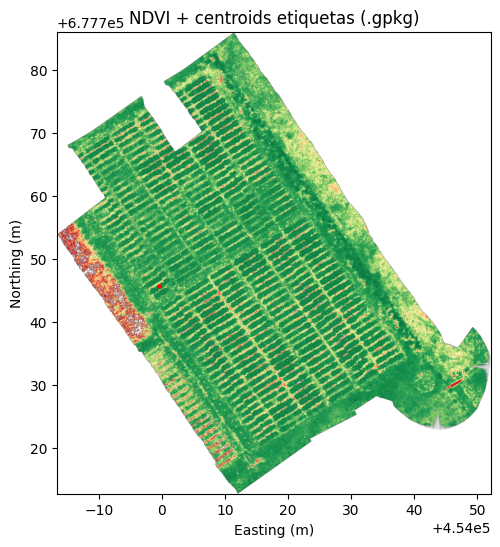

In [9]:
ndvi = ds["NDVI"].compute()
extent = (x_min, x_max, y_min, y_max)  # para imshow con extent en metros

plt.figure(figsize=(8,6))
plt.imshow(ndvi, cmap="RdYlGn", extent=extent, origin="upper")  # origin="upper" para conveniencia
# Puntos/centroides de polígonos
centroids = gdf.geometry.centroid
plt.scatter(centroids.x, centroids.y, s=5, c="red")
plt.title("NDVI + centroids etiquetas (.gpkg)")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.show()

In [10]:
centroids

0    POINT (453999.572 677745.693)
dtype: geometry

In [11]:
epsg

'EPSG:32618'

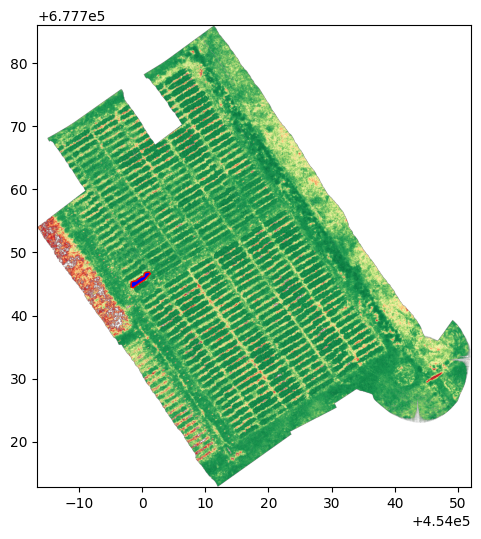

In [13]:
fig, ax = plt.subplots(figsize=(8,6))
ax.imshow(ndvi, cmap="RdYlGn", extent=(x_min, x_max, y_min, y_max), origin="upper")
gdf.plot(ax=ax, edgecolor="red", facecolor="blue", linewidth=1)
plt.show()

## 2.3 Guardar el zarr actualizado

In [14]:
# -----------------------------
# Escribir al Zarr con mode="a"
# -----------------------------
# ds.to_zarr(ZARR_PATH, mode="a", consolidated=True, align_chunks=True)


# print(f"✅ Zarr actualizado con CRS/transform y saneamiento aplicado.")

c:\Users\JMONTOYA\Documents\personal_projects\thesis\.venv\Lib\site-packages\zarr\api\asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


✅ Zarr actualizado con CRS/transform y saneamiento aplicado.


# 3. Guardar etiquetas rasterizadas como GeoTIFF con metadatos correctos

In [17]:
# --- Rutas ---
labels_path = PathManager().get_abs_path_file("labels_export.gpkg")

# --- Abrir Zarr ---
ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})
template = ds["NDVI"] if "NDVI" in ds.data_vars else ds["reflectance"].isel(band=0, drop=True)
transform = ds.rio.transform()
epsg = ds.rio.crs
height, width = ds.rio.shape


# --- Máscaras de validez ---
veg_mask = ds["veg_mask"].values.astype(bool)          # True = vegetación
mask_nodata = ds["mask_nodata"].values.astype(np.uint8)  # 0 = válido
valid_mask = veg_mask & (mask_nodata == 0)

# --- Cargar etiquetas (GeoPackage) ---
gdf = gpd.read_file(labels_path, layer='labels2')
if gdf.crs is None:
    raise ValueError("El GeoPackage no tiene CRS definido.")
if str(gdf.crs) != str(epsg):
    gdf = gdf.to_crs(epsg)

# Verificar campo 'class'
if "class" not in gdf.columns:
    raise ValueError("No se encontró el campo 'class' en la capa de etiquetas.")
print("Valores únicos en 'class' del GeoPackage:", sorted(gdf["class"].dropna().unique().tolist()))

C:\Users\JMONTOYA\AppData\Local\Temp\ipykernel_5516\1614534870.py:5: UserWarning: The specified chunks separate the stored chunks along dimension "band" starting at index 64. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})


Valores únicos en 'class' del GeoPackage: [0, 1, 2, 3]


In [18]:
gdf

,binary,plot,rep,entry,class,geometry
0,1,8,1,1,3,"MULTIPOLYGON (((453998.193 677745.334, 453998...."
1,0,17,3,10,0,"MULTIPOLYGON (((454016.451 677721.86, 454016.3..."
2,1,8,1,8,1,"MULTIPOLYGON (((454038.002 677735.139, 454037...."
3,1,24,3,2,2,"MULTIPOLYGON (((454003.545 677777.041, 454003...."
4,1,24,3,2,2,"MULTIPOLYGON (((454004.657 677776.558, 454004...."
...,...,...,...,...,...,...
330,0,18,3,1,0,"MULTIPOLYGON (((454015.189 677726.834, 454015...."
331,0,18,3,1,0,"MULTIPOLYGON (((454015.809 677726.041, 454015...."
332,0,17,3,10,0,"MULTIPOLYGON (((454016.958 677725.23, 454016.9..."
333,0,17,3,10,0,"MULTIPOLYGON (((454017.458 677724.079, 454017...."


In [19]:
# --- Rasterización multiclase ---
# Construye (geom, valor_clase) para cada polígono; NaN o faltantes se interpretan como 0

nodata_label = 255

shapes = []
for _, row in gdf.iterrows():
    geom = row.geometry
    if geom is None or geom.is_empty:
        continue
    cls = int(row["class"]) if not np.isnan(row["class"]) else nodata_label
    shapes.append((geom, cls))

# Rasterizar en uint8; fill=0 (no afectado / fuera de válido)
burn_multiclass = features.rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=transform,
    fill=nodata_label,
    all_touched=True,             # más inclusivo en bordes; cambia a False si deseas centro-en
    dtype="uint8"
)

# Aplicar semántica veg-válido: fuera de válido => 0
burn_multiclass[~valid_mask] = nodata_label

# --- Derivar binario desde multiclase ---
condition_0 = (burn_multiclass == 0)
condition_1 = (burn_multiclass > 0) & (burn_multiclass != nodata_label) 

binary = np.where(condition_1, 1, np.where(condition_0, 0, np.nan))
# binary[~valid_mask] = np.nan

# binary = ((burn_multiclass > 0) & (burn_multiclass != nodata_label)).astype("uint8") 

# --- QC: conteos por clase y proporción válida ---
unique_classes, counts = np.unique(burn_multiclass, return_counts=True)
class_counts = dict(zip(unique_classes.tolist(), counts.tolist()))
prop_valid_pixels = float(valid_mask.sum()) / float(valid_mask.size)

print("\n=== QC etiquetas multiclase ===")
print(f"Conteos por clase: {class_counts}")
print(f"Proporción de píxeles veg-válidos en el cubo: {prop_valid_pixels:.3f}")
print(f"Pixeles binarios positivos (==1): {np.sum(binary == 1)}")
print(f"Pixeles binarios positivos (==0): {np.sum(binary == 0)}")
print(f"Pixeles binarios fuera de máscara (==nan): {np.sum(np.isnan(binary))}")


=== QC etiquetas multiclase ===
Conteos por clase: {0: 501922, 1: 542394, 2: 368663, 3: 335660, 255: 10834441}
Proporción de píxeles veg-válidos en el cubo: 0.481
Pixeles binarios positivos (==1): 1246717
Pixeles binarios positivos (==0): 501922
Pixeles binarios fuera de máscara (==nan): 10834441


In [20]:
# --- Guardar GeoTIFF multiclase ---
profile_multi = {
    "driver": "GTiff",
    "height": height,
    "width": width,
    "count": 1,
    "dtype": "uint8",
    "crs": epsg,
    "transform": transform,
    "tiled": True,
    "blockxsize": 256,
    "blockysize": 256,
    "compress": "deflate",
    "predictor": 2,
    "nodata": nodata_label       # 255 = fuera de válido
}


tiff_path = Path(INTERIM_DATA + "/labels_multiclass.tif")

with rasterio.open(tiff_path.as_posix(), "w", **profile_multi) as dst:
    dst.write(burn_multiclass, 1)
    dst.update_tags(
        DESCRIPTION="Rasterized labels from QGIS polygons (multiclass)",
        SOURCE_VECTOR=str(labels_path),
        FIELD="class",
        SEMANTICS="0=no-affected/outside-valid; >0=affected classes",
        ALL_TOUCHED="True",
        MASK_RULE="veg_mask & (mask_nodata==0)"
    )

print(f"\n✅ GeoTIFF multiclase: {tiff_path}")


✅ GeoTIFF multiclase: c:\Users\JMONTOYA\Documents\personal_projects\thesis\data\interim\labels_multiclass.tif


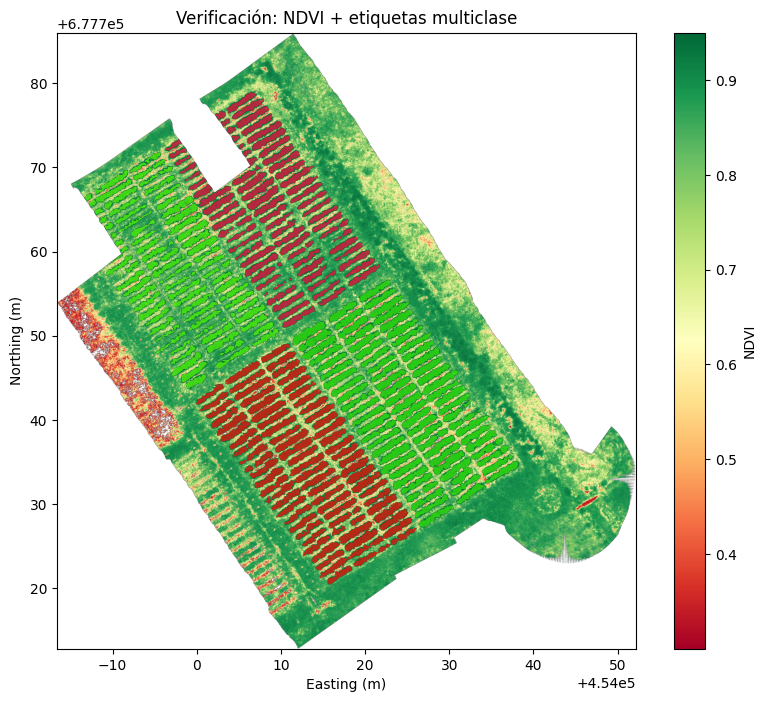

In [21]:
# --- Verificación visual rápida (NDVI + overlay) ---
ndvi = template.compute()  # cargar para graficar
x_min = transform.c
x_max = x_min + width * transform.a
y_max = transform.f
y_min = y_max + height * transform.e
extent = (x_min, x_max, y_min, y_max)

fig, ax = plt.subplots(figsize=(10, 8))
base = ax.imshow(ndvi, cmap="RdYlGn", extent=extent, origin="upper")
# conditios = burn_multiclass != 255
ax.imshow(np.ma.masked_where(burn_multiclass == 255, burn_multiclass),
          cmap="prism", alpha=0.7, extent=extent, origin="upper")
ax.set_title("Verificación: NDVI + etiquetas multiclase")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.colorbar(base, ax=ax, label="NDVI")
plt.show()

# 4. Inspeccionar el GeoTIFF exportado

C:\Users\JMONTOYA\AppData\Local\Temp\ipykernel_5516\2953987032.py:6: UserWarning: The specified chunks separate the stored chunks along dimension "band" starting at index 64. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(zarr_path, consolidated=True, chunks={"band": 64, "y": 512, "x": 512})


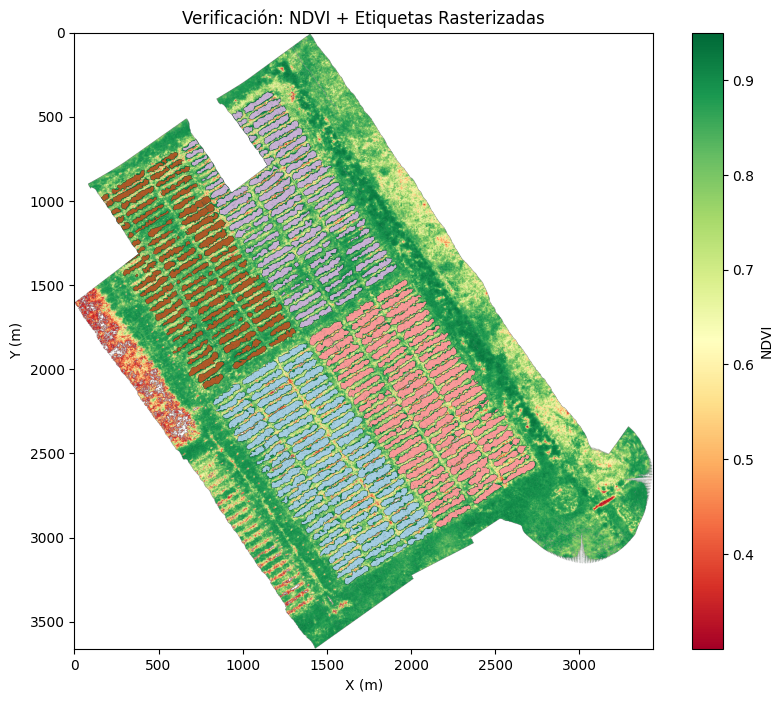

In [22]:
# --- Rutas ---
zarr_path = Path(PathManager().get_abs_path_folder("masked_reflectance.zarr"))
labels_tiff_path = Path(PathManager().get_abs_path_file("labels_multiclass.tif"))

# --- Abrir Zarr y tomar NDVI ---
ds = xr.open_zarr(zarr_path, consolidated=True, chunks={"band": 64, "y": 512, "x": 512})
if "NDVI" not in ds:
    raise ValueError("NDVI no está disponible en el Zarr.")
ndvi = ds["NDVI"].compute()  # Cargar NDVI en memoria para graficar

# --- Obtener transform y CRS ---
crs = ndvi.rio.crs
transform = ndvi.rio.transform()
height, width = ndvi.shape

# Calcular extent para imshow
x_min = transform.c
x_max = transform.c + width * transform.a
y_max = transform.f
y_min = transform.f + height * transform.e  # e es negativo
extent = (x_min, x_max, y_min, y_max)

# --- Abrir GeoTIFF de etiquetas ---
with rasterio.open(labels_tiff_path) as src:
    labels = src.read(1)

# --- Graficar overlay ---
fig, ax = plt.subplots(figsize=(10, 8))
img = ax.imshow(ndvi, cmap="RdYlGn", extent=extent, origin="upper")
# Overlay de etiquetas con transparencia
ax.imshow(np.ma.masked_where(labels == 255, labels), 
          cmap="Paired", alpha=1, extent=extent, origin="upper")

ax.set_title("Verificación: NDVI + Etiquetas Rasterizadas")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
plt.colorbar(img, ax=ax, label="NDVI")
plt.show()
